Import Library

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

Load Train CSV

In [2]:
train_df = pd.read_csv(
    "../data/train/train.csv"
)

print(train_df.shape)

train_df.head()

(240681, 5)


,image_path,cardiomegaly,tb,source,combined_label
0,../data/raw/chexpert/train/patient15208/study8...,-1,-1,chexpert,-1_-1
1,../data/raw/chexpert/train/patient54140/study1...,-1,-1,chexpert,-1_-1
2,../data/raw/chexpert/train/patient14326/study1...,0,-1,chexpert,0_-1
3,../data/raw\chestxray14/images/00013646_000.png,0,-1,nih,0_-1
4,../data/raw/chexpert/train/patient03122/study3...,-1,-1,chexpert,-1_-1


Ambil Sample Image

In [3]:
sample_path = train_df.iloc[0]["image_path"]

sample_path

'../data/raw/chexpert/train/patient15208/study8/view1_frontal.jpg'

Load Image

In [4]:
image = cv2.imread(sample_path)

image.shape

(320, 390, 3)

Convert ke RGB

In [5]:
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

Tampilkan Image

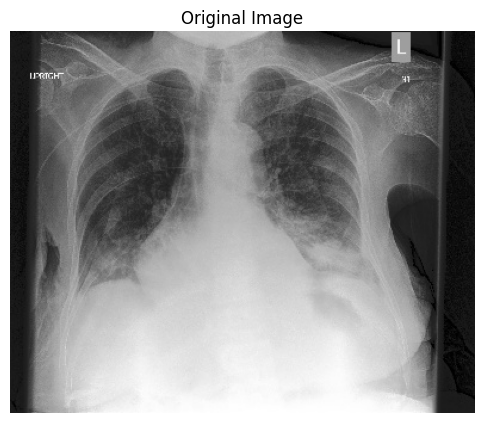

In [6]:
plt.figure(figsize=(6,6))

plt.imshow(image_rgb)

plt.axis("off")

plt.title("Original Image")

plt.show()

Resize Image

In [7]:
resized_image = cv2.resize(
    image_rgb,
    (224, 224)
)

print(resized_image.shape)

(224, 224, 3)


Tampilkan Resize

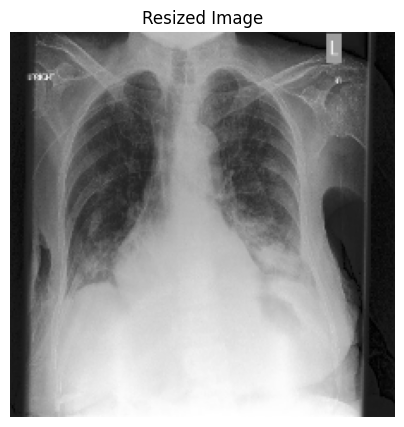

In [8]:
plt.figure(figsize=(5,5))

plt.imshow(resized_image)

plt.axis("off")

plt.title("Resized Image")

plt.show()

Normalization

In [9]:
normalized_image = resized_image / 255.0

normalized_image.min(), normalized_image.max()

(np.float64(0.0), np.float64(1.0))

CLAHE Enhancement

In [10]:
#Convert ke grayscale
gray_image = cv2.cvtColor(
    resized_image,
    cv2.COLOR_RGB2GRAY
)

In [11]:
#Terapkan CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_image = clahe.apply(gray_image)

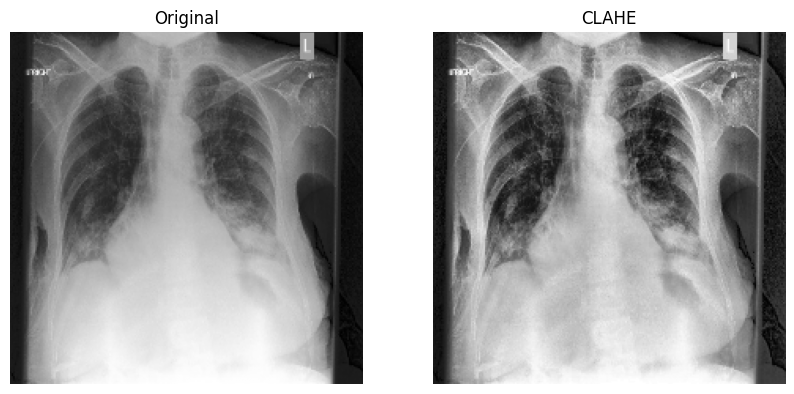

In [12]:
#Tampilkan Hasil
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray_image, cmap="gray")
plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE")

plt.axis("off")

plt.show()